Step 1: Import Required Libraries

In [ ]:
# Basic Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

# TensorFlow & Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Google Colab Upload
from google.colab import files

Step 2: Data Collection

In [ ]:
# Upload dataset zip file
uploaded = files.upload()

# Extract dataset
with zipfile.ZipFile("brain_mri.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

dataset_path = "/content/brain_mri"

Saving brain_mri.zip to brain_mri.zip


Step 3:Data Processing

In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

Step 4 : Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

Step 5 : Create Training and Validation Sets

In [ ]:
import os
# The zip extracted directly into /content/ creating 'yes' and 'no' folders
dataset_path = '/content/'

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    classes=['no', 'yes']
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    classes=['no', 'yes']
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


Step 6 : Visualize Sample Images

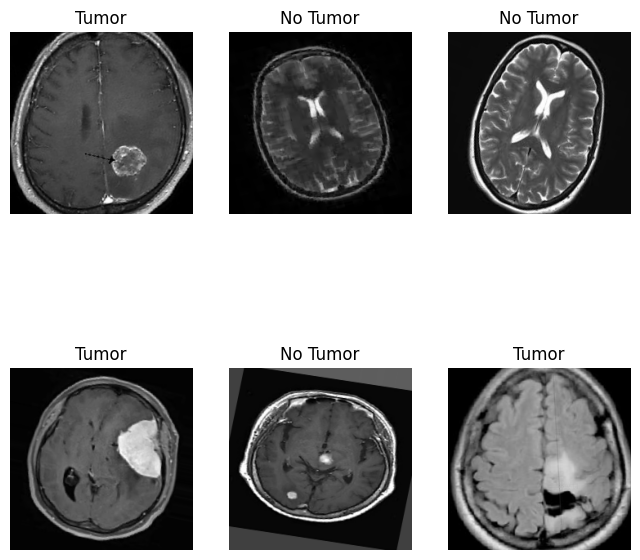

In [ ]:
plt.figure(figsize=(8,8))
for i in range(6):
    img, label = next(train_data)
    plt.subplot(2,3,i+1)
    plt.imshow(img[0])
    plt.title("Tumor" if label[0]==1 else "No Tumor")
    plt.axis('off')
plt.show()

Step 7 : Model Design

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 8 : Model Compilation

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,985 (42.61 MB)

 Trainable params: 11,169,537 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

Step 9: Model Training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.5566 - loss: 3.0659 - val_accuracy: 0.6800 - val_loss: 0.6455
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 7s/step - accuracy: 0.6682 - loss: 0.8443 - val_accuracy: 0.5800 - val_loss: 0.6187
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.6731 - loss: 0.7740 - val_accuracy: 0.6200 - val_loss: 0.6102
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step - accuracy: 0.7191 - loss: 0.6270 - val_accuracy: 0.6200 - val_loss: 0.7022
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 93s 7s/step - accuracy: 0.7393 - loss: 0.5637 - val_accuracy: 0.6200 - val_loss: 0.7531
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 36s 5s/step - accuracy: 0.7233 - loss: 0.5071 - val_accuracy: 0.6200 - val_loss: 0.7648
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 5s/step - accuracy: 0.7553 - loss: 0.5417 - val_accuracy: 0.6200 - val_loss: 0.8317
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 37s 5s/step - accuracy: 0.7453 - loss: 0.6037 - val_accuracy: 0.6200 - val_loss: 0.9752
Epoch 9/

Step 10: Plot Training Performance

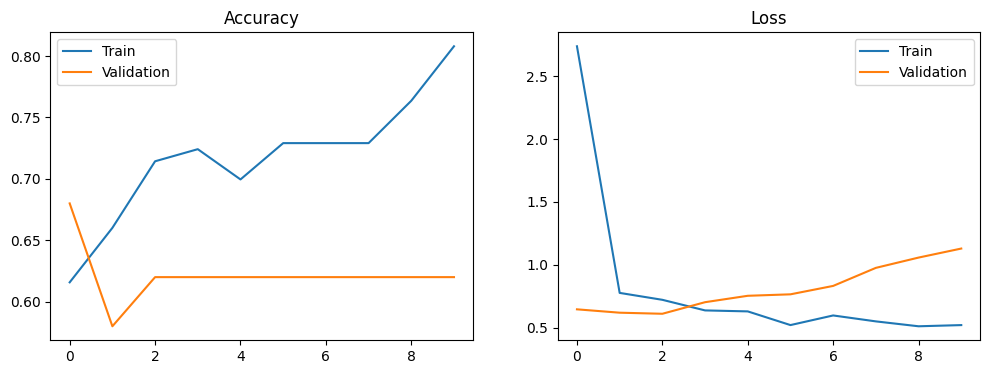

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.show()

Step 11: Model Evaluation

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 624ms/step


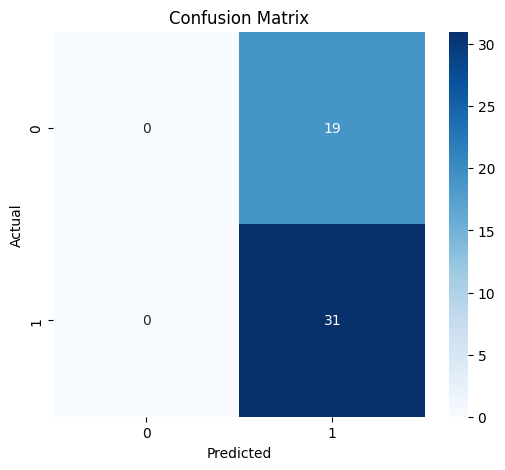


Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.00      0.00      0.00        19
       Tumor       0.62      1.00      0.77        31

    accuracy                           0.62        50
   macro avg       0.31      0.50      0.38        50
weighted avg       0.38      0.62      0.47        50



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
val_data.reset()

predictions = model.predict(val_data)
y_pred = (predictions > 0.5).astype(int).reshape(-1)
y_true = val_data.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=['No Tumor','Tumor']))

Step 12: Result Analysis

In [ ]:
print("\nSample Tumor Confidence Scores:")
for i in range(5):
    print(f"Image {i+1} Tumor Probability: {round(predictions[i][0]*100,2)}%")


Sample Tumor Confidence Scores:
Image 1 Tumor Probability: 87.3499984741211%
Image 2 Tumor Probability: 95.47000122070312%
Image 3 Tumor Probability: 91.33999633789062%
Image 4 Tumor Probability: 91.69000244140625%
Image 5 Tumor Probability: 90.55999755859375%


In [ ]:
import numpy as np

# Ensure y_pred and y_true are defined by running the evaluation cell (iWkDNsI05L9G) first
try:
    misclassified = np.where(y_pred != y_true)[0]
    print("Number of Misclassified Images:", len(misclassified))
except NameError as e:
    print(f"Error: {e}. Please run the Model Evaluation cell (Step 11) before running this cell.")

Error: name 'y_pred' is not defined. Please run the Model Evaluation cell (Step 11) before running this cell.


Step 13 : Predict Single MRI Image

In [ ]:
from tensorflow.keras.preprocessing import image
import os

# The correct path based on your directory structure
img_path = "/content/yes/Y1.jpg"

if os.path.exists(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    probability = prediction[0][0]

    if probability > 0.5:
        print("Tumor Detected")
    else:
        print("No Tumor")

    print("Tumor Probability:", round(probability*100,2), "%")
else:
    print(f"Error: The file {img_path} was not found. Please check the filename.")
    # List files in /content/yes/ to help find a valid filename
    if os.path.exists('/content/yes/'):
        print("Available images in 'yes' folder:", os.listdir('/content/yes/')[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Tumor Detected
Tumor Probability: 97.62 %
